In [1]:
import os
os.environ["DDE Backend"]="pytorch"

In [2]:
import deepxde as dde 
import numpy as np 
import torch

No backend selected.
Finding available backend...
Found pytorch
Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [4]:
def expo(x,y):
    dy_dx=dde.grad.jacobian(y,x,i=0,j=0)
    return dy_dx-y

In [7]:
geom=dde.geometry.Interval(0,1)
bc1=dde.icbc.DirichletBC(geom,lambda x:1,lambda x,on_boundary:on_boundary and np.isclose(x[0],0))
bc2=dde.icbc.DirichletBC(geom,lambda x:np.exp(1),lambda x,on_boundary:on_boundary and np.isclose(x[0],1))
data=dde.data.PDE(
    geom,
    expo,
    [bc1,bc2],
    num_domain=2000,
    num_boundary=100
)

In [8]:
net=dde.nn.FNN([1]+[32]*3+[1],"tanh","Glorot normal")
model=dde.Model(data,net)

In [9]:
model.compile("adam",lr=1e-3)
model.train(iterations=10000)
model.compile("L-BFGS")
losshistory,train_state=model.train()

Compiling model...
'compile' took 3.399977 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.10e-02, 1.00e+00, 6.51e+00]    [1.10e-02, 1.00e+00, 6.51e+00]    []  
1000      [3.66e-03, 6.77e-11, 8.85e-06]    [3.66e-03, 6.77e-11, 8.85e-06]    []  
2000      [1.47e-03, 8.29e-08, 1.04e-05]    [1.47e-03, 8.29e-08, 1.04e-05]    []  
3000      [8.32e-04, 7.25e-08, 4.72e-07]    [8.32e-04, 7.25e-08, 4.72e-07]    []  
4000      [6.06e-04, 3.37e-07, 1.19e-07]    [6.06e-04, 3.37e-07, 1.19e-07]    []  
5000      [4.91e-04, 7.58e-08, 1.42e-07]    [4.91e-04, 7.58e-08, 1.42e-07]    []  
6000      [4.15e-04, 1.72e-06, 2.89e-06]    [4.15e-04, 1.72e-06, 2.89e-06]    []  
7000      [3.52e-04, 1.03e-06, 2.32e-05]    [3.52e-04, 1.03e-06, 2.32e-05]    []  
8000      [3.56e-04, 2.89e-04, 1.90e-03]    [3.56e-04, 2.89e-04, 1.90e-03]    []  
9000      [2.49e-04, 7.15e-08, 5.39e-08]    [2.49e-04, 7.15e-08, 5.39e-08]    []  
10000     [2.04

Saving loss history to d:\psd\loss.dat ...
Saving training data to d:\psd\train.dat ...
Saving test data to d:\psd\test.dat ...


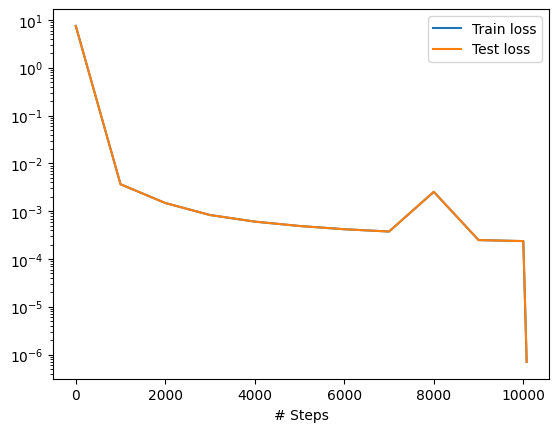

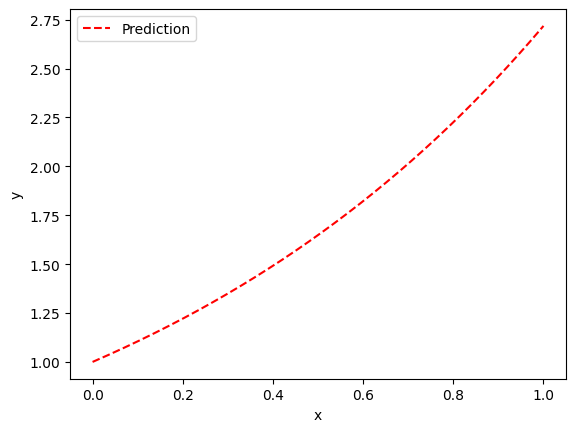

In [10]:
import matplotlib.pyplot as plt
dde.saveplot(losshistory,train_state,issave=True,isplot=True)